---
## Step 1 — Setup Libraries and Read The datatest ##

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the datatest
df = pd.read_csv('netflix_titles.csv')

# Showing first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


---
## Step 2 — Data Cleaning & Basic Analysis ##

In [9]:
# 1. Handling missing values
# We fill 'Unknown' for categorical columns where data is missing
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

# We drop rows where critical information like 'date_added' or 'rating' is missing
df = df.dropna(subset=['date_added', 'rating'])

# 2. Feature Engineering: Extracting the year
# We strip whitespace and convert the string date to a datetime object, then extract the year
df['year_added'] = pd.to_datetime(df['date_added'].str.strip()).dt.year

# 3. Data Aggregation
# Counting the total number of titles added per year and sorting by year
yearly_content = df['year_added'].value_counts().sort_index()

# --- FINAL CHECK ---
print("Total missing values after cleaning:")
print(df.isnull().sum().sum())

print("\nContent added in the last 5 years:")
print(yearly_content.tail())

Total missing values after cleaning:
832

Content added in the last 5 years:
year_added
2017    1186
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


---
## Step 3 — Visualization: The Heatmap & Trends ##

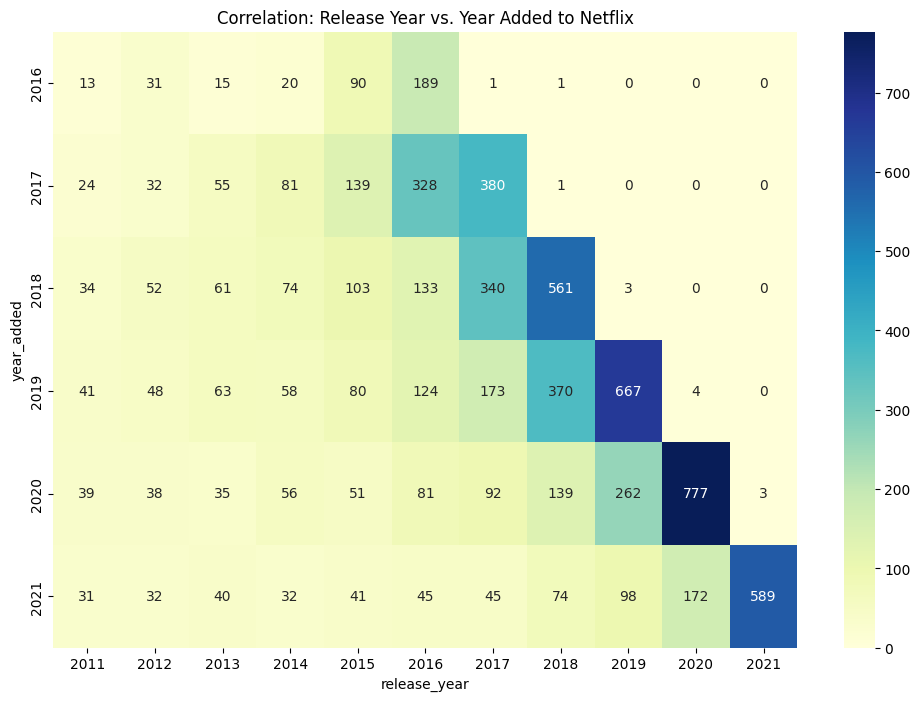

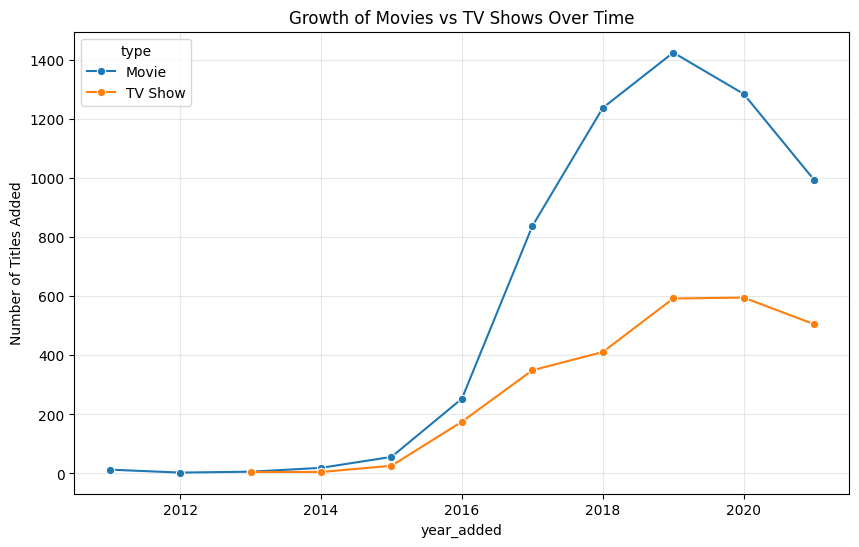

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a pivot table for the Heatmap
subset = df[(df['year_added'] > 2015) & (df['release_year'] > 2010)]
heatmap_data = subset.groupby(['year_added', 'release_year']).size().unstack(fill_value=0)

# 2. Draw the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Correlation: Release Year vs. Year Added to Netflix")
plt.show()

# 3. Content Type Trend (Fixed Line Chart)
# We first create a small summary table to avoid index errors
trend_data = df[df['year_added'] > 2010].groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_data, x='year_added', y='count', hue='type', marker='o')
plt.title("Growth of Movies vs TV Shows Over Time")
plt.ylabel("Number of Titles Added")
plt.grid(True, alpha=0.3)
plt.show()

---
## Step 4 — The Final Story (Pie Chart) ##

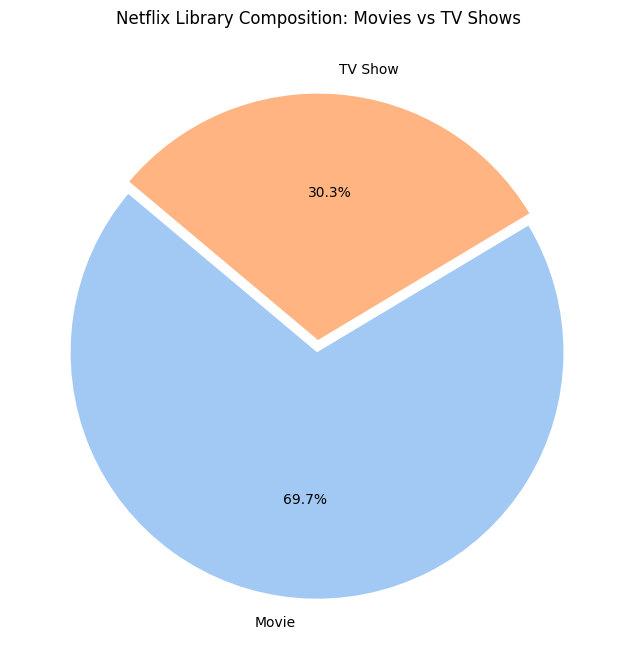

In [11]:
# 1. Prepare data for the Pie Chart
type_counts = df['type'].value_counts()

# 2. Create the plot
plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')[0:2]

plt.pie(type_counts, 
        labels=type_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=(0.05, 0)) # Pulls the 'Movie' slice out slightly for emphasis

plt.title("Netflix Library Composition: Movies vs TV Shows")
plt.show()

## Executive Summary & Interpretation

Through this data analysis, I have uncovered several key insights regarding Netflix's market strategy:

1. **Library Composition:** Netflix remains a movie-dominant platform, with **69.7%** of its library consisting of Movies compared to **30.3%** for TV Shows.
2. **Content Freshness:** The correlation heatmap reveals that Netflix prioritizes "Newness." A significant portion of the content is added to the platform within **1-2 years** of its original release date.
3. **Growth Patterns:** Content additions saw a massive surge starting in **2016**, peaking in **2019**. The subsequent slight decline in 2020-2021 likely reflects the global production slowdown during the pandemic.
4. **Data Hygiene:** The dataset was successfully cleaned by handling missing values in 'Director', 'Cast', and 'Country' columns, ensuring the integrity of the statistical visualizations.